# Pore Network Model Multiphase Simulation

__Author(s):__ Masa Prodanovic

__Last Update:__ Sep. 2025

Copyright © 2025 Digital Porous Media Team. All rights reserved.

---


__Download Finney sphere pack image from Digital Rocks Portal__

In [510]:
file_url = "https://web.corral.tacc.utexas.edu/digitalporousmedia/DRP-47/A%20packing%20of%20equal%20spheres/Example%20discretization%20(volumetric%20image)/spheres_a10_dx0.04_n500_segmented_unsigned_char.raw"
filename = "spheres_a10_dx0.04_n500_segmented_unsigned_char.raw"

import requests # library for file download
r = requests.get(file_url, stream = True) 
  
with open(filename,"wb") as f: 
    for chunk in r.iter_content(chunk_size=1024): 
  
         # writing one chunk at a time to pdf file 
         if chunk: 
             f.write(chunk)

Read the data into a 3D array.

In [512]:
import numpy as np

# the file is binary (.raw) file, and requires information from the webpage on how to read it.
width  = 500
height = 500
slices = 500

dtype  = 'u1' #8-bit data (unsigned)
byte = '<'  # little endian byte order

filename = "spheres_a10_dx0.04_n500_segmented_unsigned_char.raw"
# read data from file
datatype = byte + dtype    
alldata = np.fromfile(filename, dtype=datatype, sep="")
im = alldata.reshape([slices, height, width])

In [513]:
print('Image shape')
print(im.shape)

Image shape
(500, 500, 500)


Imports for PoreSpy
Following: https://github.com/PMEAL/OpenPNM/blob/dev/examples/notebooks/networks/extraction/predicting_effective_permeability_of_berea.ipynb

In [515]:
import os
import imageio
import scipy as sp
import numpy as np
import openpnm as op
import porespy as ps
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
np.set_printoptions(precision=4)
np.random.seed(10)
%matplotlib inline

Porosity
0.361831936


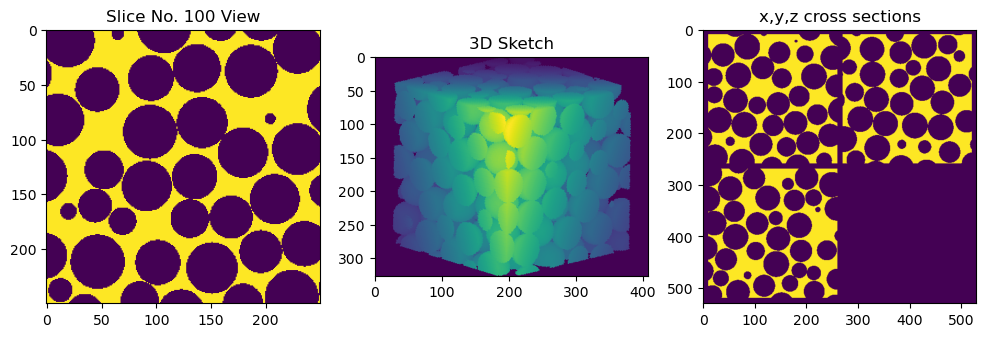

In [516]:
# Make image smaller (250 cube)
# ~ inverts phases which is necessary in this case, but that depends on how solids and pores are labeled in the original
# Porosity below value will tell you if you got the phases right.
im = ~np.array(im, dtype=bool)[:250, :250, :250]

#do not make anything smaller
#im = ~np.array(im, dtype=bool)

print('Porosity')
print(ps.metrics.porosity(im))

#Plot image
fig, ax = plt.subplots(1, 3, figsize=(12,5))
ax[0].imshow(im[:, :, 100]);
ax[1].imshow(ps.visualization.show_3D(im));
ax[2].imshow(ps.visualization.show_planes(im))
#ax[2].imshow(ps.visualization.sem(im));
ax[0].set_title("Slice No. 100 View");
ax[1].set_title("3D Sketch");
ax[2].set_title("x,y,z cross sections");
plt.show()

In [517]:
# snow object will have network results
dx = 1.0  # voxel_size
snow = ps.networks.snow2(im, voxel_size=dx)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Extracting pore and throat properties:   0%|          | 0/1204 [00:00<?, ?it/s]

In [518]:
#pn, geo = op.io.PoreSpy.import_data(snow.network)
pn = op.io.network_from_porespy(snow.network)
print(pn)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x3214acfa0>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                  2737 / 2737
  3  pore.coords                                                   1204 / 1204
  4  pore.region_label                                             1204 / 1204
  5  pore.phase                                                    1204 / 1204
  6  throat.phases                                                 2737 / 2737
  7  pore.region_volume                                            1204 / 1204
  8  pore.equivalent_diameter                                      1204 / 1204
  9  pore.local_peak                                               1204 / 1204
 10 

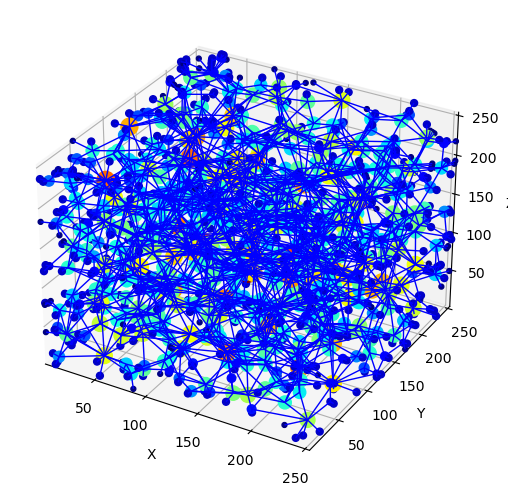

In [519]:
fig, ax = plt.subplots(figsize=[5, 5])
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  size_by=pn["pore.inscribed_diameter"],
                                  color_by=pn["pore.inscribed_diameter"],
                                  markersize=200)
op.visualization.plot_connections(network=pn, ax=fig)
plt.show()

In [520]:
# output a file that can be visualized in ParaView
op.io.project_to_vtk(project=pn.project)

# this enables overlay of the network and pore/grain surface in 
im = ps.tools.align_image_with_openpnm(im)
imageio.volsave('image.tif', np.array(im, dtype=np.int8))

In [521]:
#reg = ps.networks.map_to_regions(regions=snow.regions, values=pn['pore.region_label'])

# Why does this work better for visualization than the above options? That said, \
# I am not happy with snow2 result.
pn['pore.values'] = np.random.rand(pn.Np)
reg = ps.networks.map_to_regions(regions=snow.regions, values=pn['pore.values'])

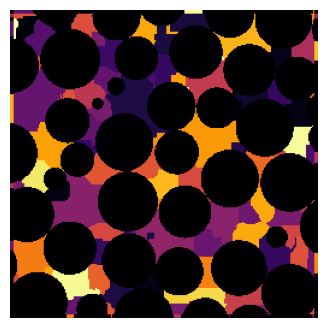

In [522]:
fig = plt.figure(figsize=[4, 4])
plt.imshow(reg[:,:,100], origin='lower',cmap = 'inferno')
plt.axis('off');
plt.show()

In [523]:
# help(ps.networks.snow2)

__Network generation__ 

We're following https://openpnm.org/examples/applications/network_extraction.html \
and https://openpnm.org/examples/applications/relative_permeability.html

In [525]:
# Check that the network is topologically sound.
h = op.utils.check_network_health(pn)
print(h)

if not h:
    op.topotools.trim(network=pn, pores=h['disconnected_pores'])
    h = op.utils.check_network_health(pn)
    print(h)

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


In [526]:
# Make a choice for pore and throat diameters (we could use inscribed or equivalent) and geometry (hydraulic conductance calculation).

pn['pore.diameter'] = pn['pore.equivalent_diameter']
pn['throat.diameter'] = pn['throat.inscribed_diameter']
pn['throat.length'] = pn['throat.total_length']
pn['throat.volume'] = (np.pi / 4) * pn['throat.diameter']**2 * pn['throat.length']

# This is one of the choices for geometrical model for pores (spheres) and
# throat (cylinders). Note that sphere model for pore will have correct volume
# since we set the pore diameter to equivalent diameter.
pn.add_model_collection(op.models.collections.geometry.spheres_and_cylinders)
pn.regenerate_models()

pn.add_model(propname='throat.hydraulic_size_factors',
             model=op.models.geometry.hydraulic_size_factors.spheres_and_cylinders)
pn.add_model(propname='throat.diffusive_size_factors',
             model=op.models.geometry.diffusive_size_factors.spheres_and_cylinders)
pn.regenerate_models()

__Set the fluid phase properties__

In [528]:
# Delete the diffusivity calculation for now
phys = op.models.collections.physics.basic
if 'throat.diffusive_conductance' in phys:
    del phys['throat.diffusive_conductance']

water = op.phase.Water(network=pn)
water.add_model_collection(phys)
water.add_model_collection(op.models.collections.phase.water)
water.regenerate_models()

# For oil, we will add water and change certain settings as oil
oil = op.phase.Water(network=pn)
oil.add_model_collection(phys)
oil.add_model_collection(op.models.collections.phase.water)
oil['pore.viscosity'] = 0.01  # Pa.s (10 cP)
oil['pore.surface_tension'] = 0.02 # N/m
oil['pore.contact_angle'] = 0
oil['pore.density'] = 800

oil['throat.viscosity'] = 0.01  # Pa.s (10 cP)
oil['throat.surface_tension'] = 0.02 # N/m
oil['throat.contact_angle'] = 0
oil['throat.density'] = 800
oil.regenerate_models()

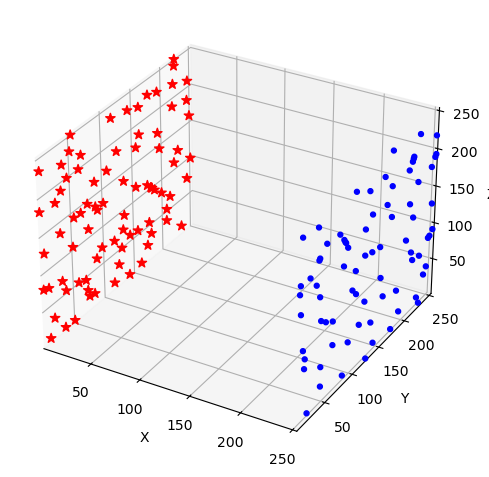

In [529]:
# Identify inlets and outlets
fig, ax = plt.subplots()
inlet = pn.pores('xmin')
outlet = pn.pores('xmax')

op.visualization.plot_coordinates(pn, inlet, c='red', marker='*', 
                                  markersize=50, ax=ax)
op.visualization.plot_coordinates(pn, outlet, c='blue', marker='.', 
                                  markersize=50, ax=ax);
plt.show()


__Invasion Percolation__ \
Assuming a drainage process, the oil(invading/non-wetting phase) will be invading the medium. 

In [531]:
# Run Invasion Percolation: oil (non-wetting phase) invades
ip = op.algorithms.InvasionPercolation(network=pn, phase=oil)
ip.set_inlet_BC(pores=inlet)
ip.run()

In [532]:
# --- Helper Functions for Permeability Calculation ---

# Updates phase occupancy based on invasion sequence
def sat_occ_update(network, nwp, wp, ip, i):
    """
        Calculates the saturation of each phase using the invasion
        sequence from either invasion percolation.
        Parameters
        ----------
        network: network
        nwp : phase
            non-wetting phase
        wp : phase
            wetting phase
        ip : IP
            invasion percolation (ran before calling this function)
        i: int
            The invasion_sequence limit for masking pores/throats that
            have already been invaded within this limit range. The
            saturation is found by adding the volume of pores and thorats
            that meet this sequence limit divided by the bulk volume.
    """
    pore_mask = ip['pore.invasion_sequence'] < i
    throat_mask = ip['throat.invasion_sequence'] < i
    sat_p = np.sum(network['pore.volume'][pore_mask])
    sat_t = np.sum(network['throat.volume'][throat_mask])
    sat1 = sat_p + sat_t
    bulk = network['pore.volume'].sum() + network['throat.volume'].sum()
    sat = sat1/bulk # Saturation of invading phase (oil)
    
    nwp['pore.occupancy'] = pore_mask
    nwp['throat.occupancy'] = throat_mask
    wp['throat.occupancy'] = 1-throat_mask
    wp['pore.occupancy'] = 1-pore_mask
    return sat # Returns invading phase saturation (So)

# Calculates flow rate using StokesFlow algorithm
# Simulates a Stokes flow given the hydraulic conductance keyword and returns the rate of inlet fluid flow.
def Rate_calc(network, phase, inlet, outlet, conductance):
    phase.regenerate_models()
    St_p = op.algorithms.StokesFlow(network=network, phase=phase)
    St_p.settings._update({'conductance' : conductance})
    St_p.set_value_BC(pores=inlet, values=1)
    St_p.set_value_BC(pores=outlet, values=0)
    St_p.run()
    val = np.abs(St_p.rate(pores=inlet, mode='group'))
    return val

__Relative Permeability Calculation__

In [534]:
# Initialize occupancy (start of simulation)
water['throat.occupancy'] = 1-pn['throat.all']
water['pore.occupancy'] = 1-pn['pore.all']
oil['pore.occupancy'] = pn['pore.all']
oil['throat.occupancy'] = pn['throat.all']

# Add multiphase conductance models
model_mp_cond = op.models.physics.multiphase.conduit_conductance
water.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
                throat_conductance='throat.hydraulic_conductance', mode='medium')
oil.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
              throat_conductance='throat.hydraulic_conductance', mode='medium')

In [535]:
Snwp_num = 20 # Number of saturation steps
max_seq = np.max([np.max(ip['pore.invasion_sequence']),
                np.max(ip['throat.invasion_sequence'])])

# Define saturation steps
start_val = max_seq // Snwp_num
stop_val = max_seq
step_val = max_seq // Snwp_num
Swparr = []
relperm_nwp = []
relperm_wp = []
start_time = time.time()

In [536]:
# Main calculation loop
for i in tqdm(range(start_val, stop_val, step_val), desc="Calculating RelPerm"):
    oil.regenerate_models()
    water.regenerate_models()
    
    # Update saturation and get current Sw
    sat_invading = sat_occ_update(network=pn, nwp=oil, wp=water, ip=ip, i=i)
    Swparr.append(1-sat_invading) # We want Sw (assuming nwp=oil invades))
    
    # Calculate absolute permeability (single phase)
    Rate_abs_nwp = Rate_calc(pn, oil, inlet, outlet, conductance = 'throat.hydraulic_conductance')
    Rate_abs_wp = Rate_calc(pn, water, inlet, outlet, conductance = 'throat.hydraulic_conductance')
    
    # Calculate effective permeability (multiphase)
    Rate_enwp = Rate_calc(pn, oil, inlet, outlet, conductance = 'throat.conduit_hydraulic_conductance')
    Rate_ewp = Rate_calc(pn, water, inlet, outlet, conductance = 'throat.conduit_hydraulic_conductance')
            
    # Calculate relative permeability
    relperm_nwp.append(Rate_enwp/Rate_abs_nwp)
    relperm_wp.append(Rate_ewp/Rate_abs_wp)

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Relative permeability calculation Done in {elapsed_time:.2f} seconds.")

Calculating RelPerm: 100%|██████████████████████| 20/20 [00:00<00:00, 24.19it/s]

Relative permeability calculation Done in 0.83 seconds.


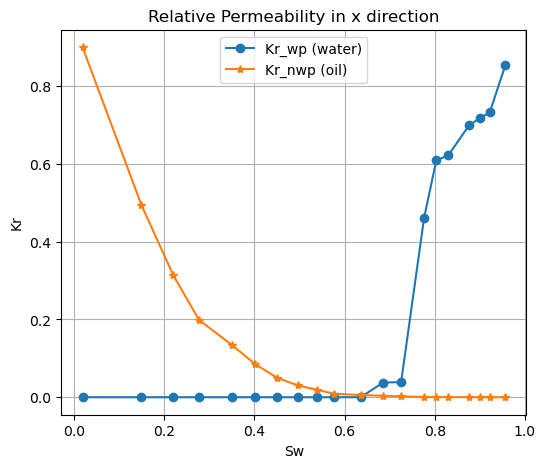

In [537]:
plt.figure(figsize=[6,5])
plt.plot(Swparr, relperm_wp, 'o-', label='Kr_wp (water)')
plt.plot(Swparr, relperm_nwp, '*-', label='Kr_nwp (oil)')
plt.xlabel('Sw')
plt.ylabel('Kr')
plt.title(f'Relative Permeability in x direction')
plt.grid(True)
plt.legend()
plt.show()